Saving Chocolate Sales.csv to Chocolate Sales (1).csv
First 5 rows:
      Sales Person    Country              Product       Date    Amount  \
0  Jehu Rudeforth         UK      Mint Chip Choco  04-Jan-22   $5,320    
1     Van Tuxwell      India        85% Dark Bars  01-Aug-22   $7,896    
2    Gigi Bohling      India  Peanut Butter Cubes  07-Jul-22   $4,501    
3    Jan Morforth  Australia  Peanut Butter Cubes  27-Apr-22  $12,726    
4  Jehu Rudeforth         UK  Peanut Butter Cubes  24-Feb-22  $13,685    

   Boxes Shipped  
0            180  
1             94  
2             91  
3            342  
4            184  

Columns:
 Index(['Sales Person', 'Country', 'Product', 'Date', 'Amount',
       'Boxes Shipped'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   1094 non-null   object
 

/tmp/ipykernel_1754/184625435.py:26: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


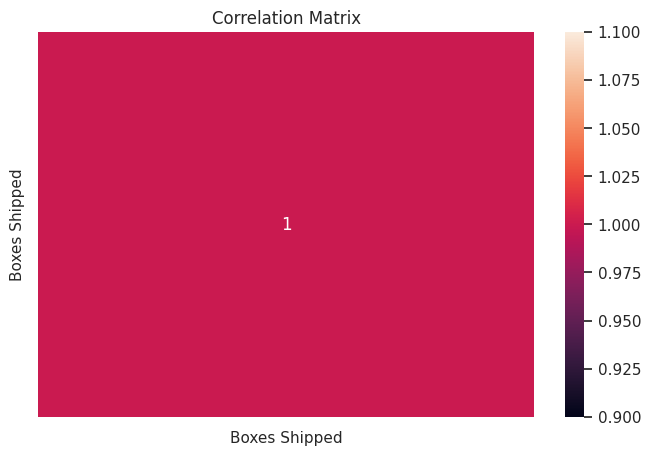


✅ Analysis Completed & File Saved!


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import files
uploaded = files.upload()


df = pd.read_csv("Chocolate Sales.csv")

print("First 5 rows:\n", df.head())

print("\nColumns:\n", df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:\n", df.isnull().sum())


df = df.drop_duplicates()


df.fillna(method='ffill', inplace=True)

if 'Quantity' in df.columns and 'Price' in df.columns:
    df['Revenue'] = df['Quantity'] * df['Price']


if 'Product' in df.columns and 'Quantity' in df.columns:
    top_products = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
    print("\nTop Products:\n", top_products.head())


if 'Revenue' in df.columns:
    print("\nTotal Revenue:", df['Revenue'].sum())


sns.set(style="whitegrid")

if 'Product' in df.columns and 'Quantity' in df.columns:
    top_products.head(10).plot(kind='bar')
    plt.title("Top Selling Chocolate Products")
    plt.xlabel("Product")
    plt.ylabel("Quantity Sold")
    plt.show()


if 'Quantity' in df.columns:
    plt.hist(df['Quantity'])
    plt.title("Sales Distribution")
    plt.xlabel("Quantity")
    plt.ylabel("Frequency")
    plt.show()


plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()




if 'Region' in df.columns and 'Revenue' in df.columns:
    region_sales = df.groupby('Region')['Revenue'].sum()
    print("\nSales by Region:\n", region_sales)


df.to_csv("Processed_Chocolate_Sales.csv", index=False)

print("\n✅ Analysis Completed & File Saved!")